# Practice using Scanpy and scVelo on mouse gastrulation

In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import cellrank as cr
import random
random.seed(123)



In [2]:
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.settings.set_figure_params('scvelo')  # for beautified visualization
#sc.logging.print_versions()

In [3]:
sc.settings.set_figure_params(dpi=80, facecolor='white')
#sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)
sc.settings.verbosity = 3

#sc.logging.print_versions()

### I/O 

In [4]:
Data = 'adata_umap_pca.h5'

In [4]:
def matrix(df):
  temp = pd.DataFrame.sparse.from_spmatrix(df)
  return temp

### Load data

In [6]:
adata = sc.read(Data)

### Analysis

In [7]:
adata.var

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'X_umap', 'X_pca'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

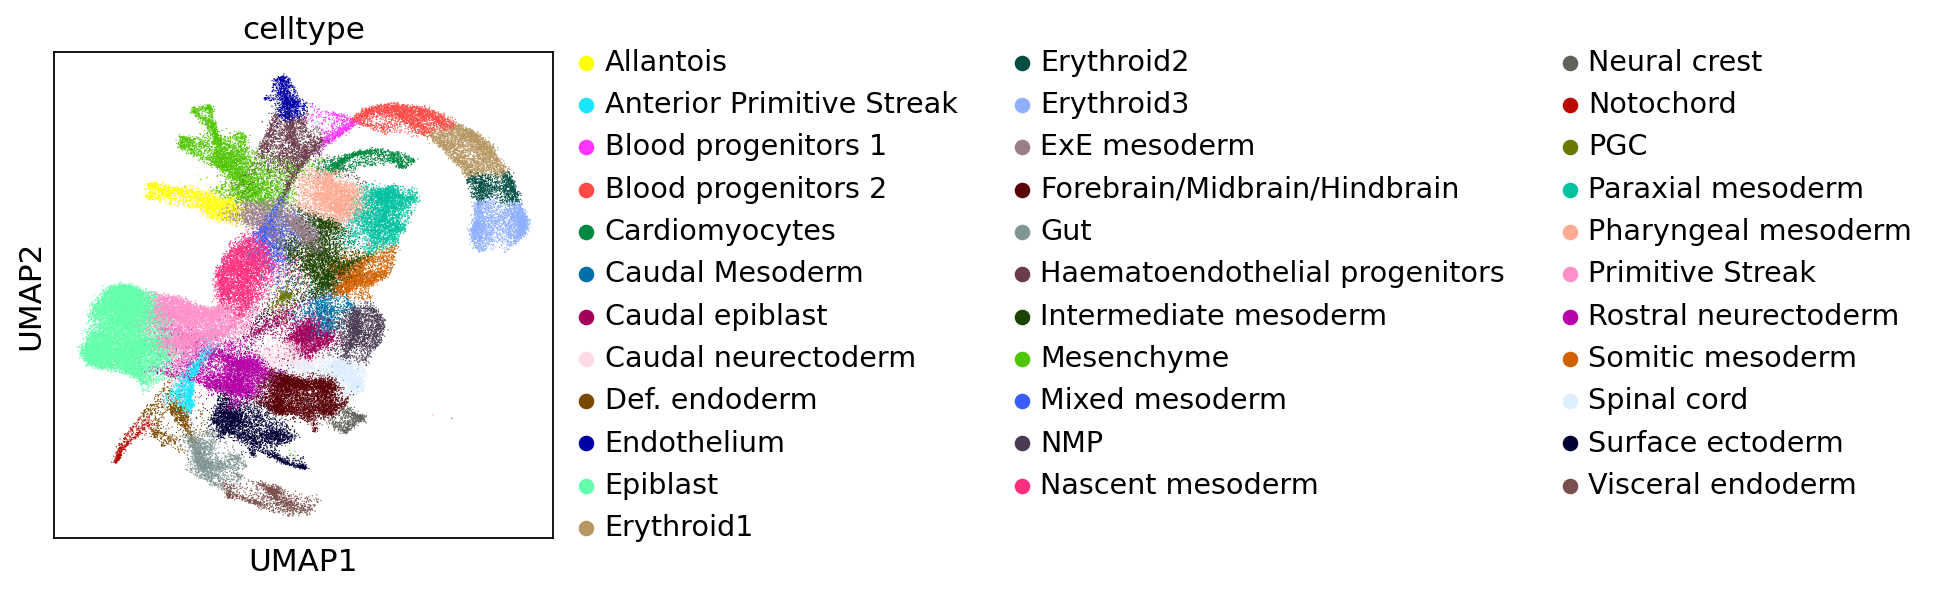

In [8]:
sc.pl.umap(adata, color='celltype')

In [9]:
endo = adata[adata.obs['celltype'].isin(['Anterior Primitive Streak', 'Def. endoderm', 'Gut', 'Visceral endoderm'])].copy()

In [10]:
del adata

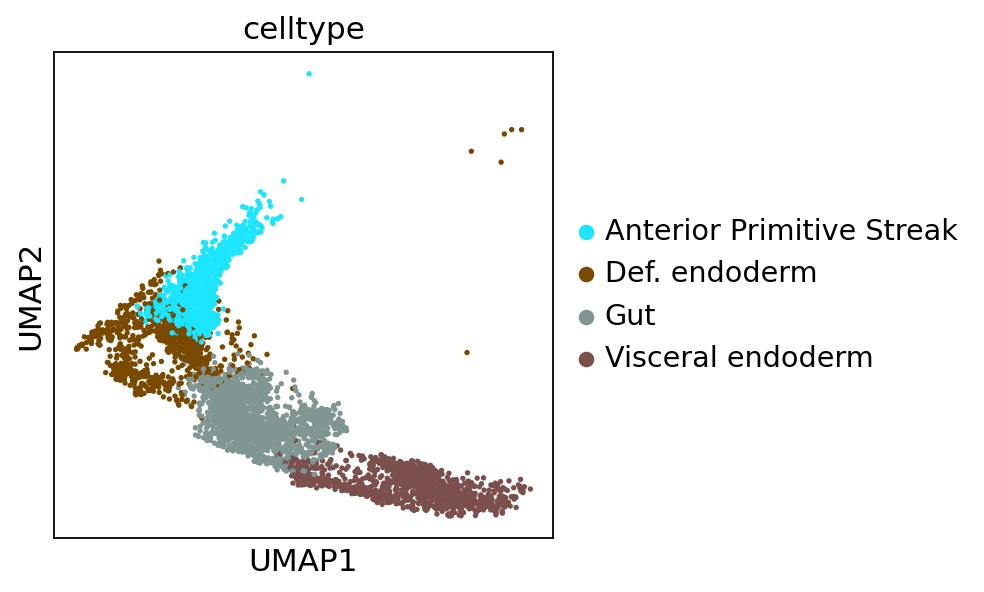

In [10]:
sc.pl.umap(endo, color='celltype')

In [11]:
endo

AnnData object with n_obs × n_vars = 5066 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'celltype_colors'
    obsm: 'X_umap', 'X_pca'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [19]:
endo.write('endo_test.h5')

In [6]:
endo = sc.read('endo_test.h5')

In [13]:
scv.pp.filter_and_normalize(endo, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(endo, n_pcs=30, n_neighbors=30)


Filtered out 47238 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Exctracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:06) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [14]:
endo

AnnData object with n_obs × n_vars = 5066 × 2000
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'celltype_colors', 'neighbors'
    obsm: 'X_umap', 'X_pca'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [16]:
scv.tl.recover_dynamics(endo)

recovering dynamics
    finished (0:18:36) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [17]:
scv.tl.velocity(endo, mode='dynamical')
scv.tl.velocity_graph(endo)

computing velocities
    finished (0:00:06) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph
    finished (0:00:08) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


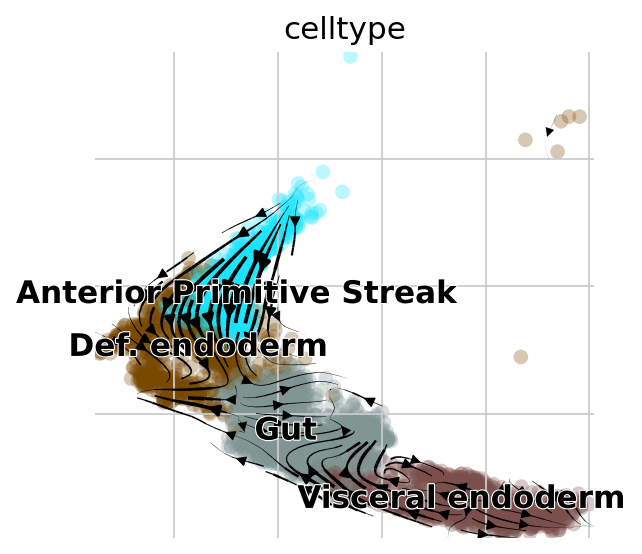

In [18]:
scv.pl.velocity_embedding_stream(endo, basis='umap',color='celltype')

In [5]:
top_genes = endo.var['fit_likelihood'].sort_values(ascending=False).index[:300]

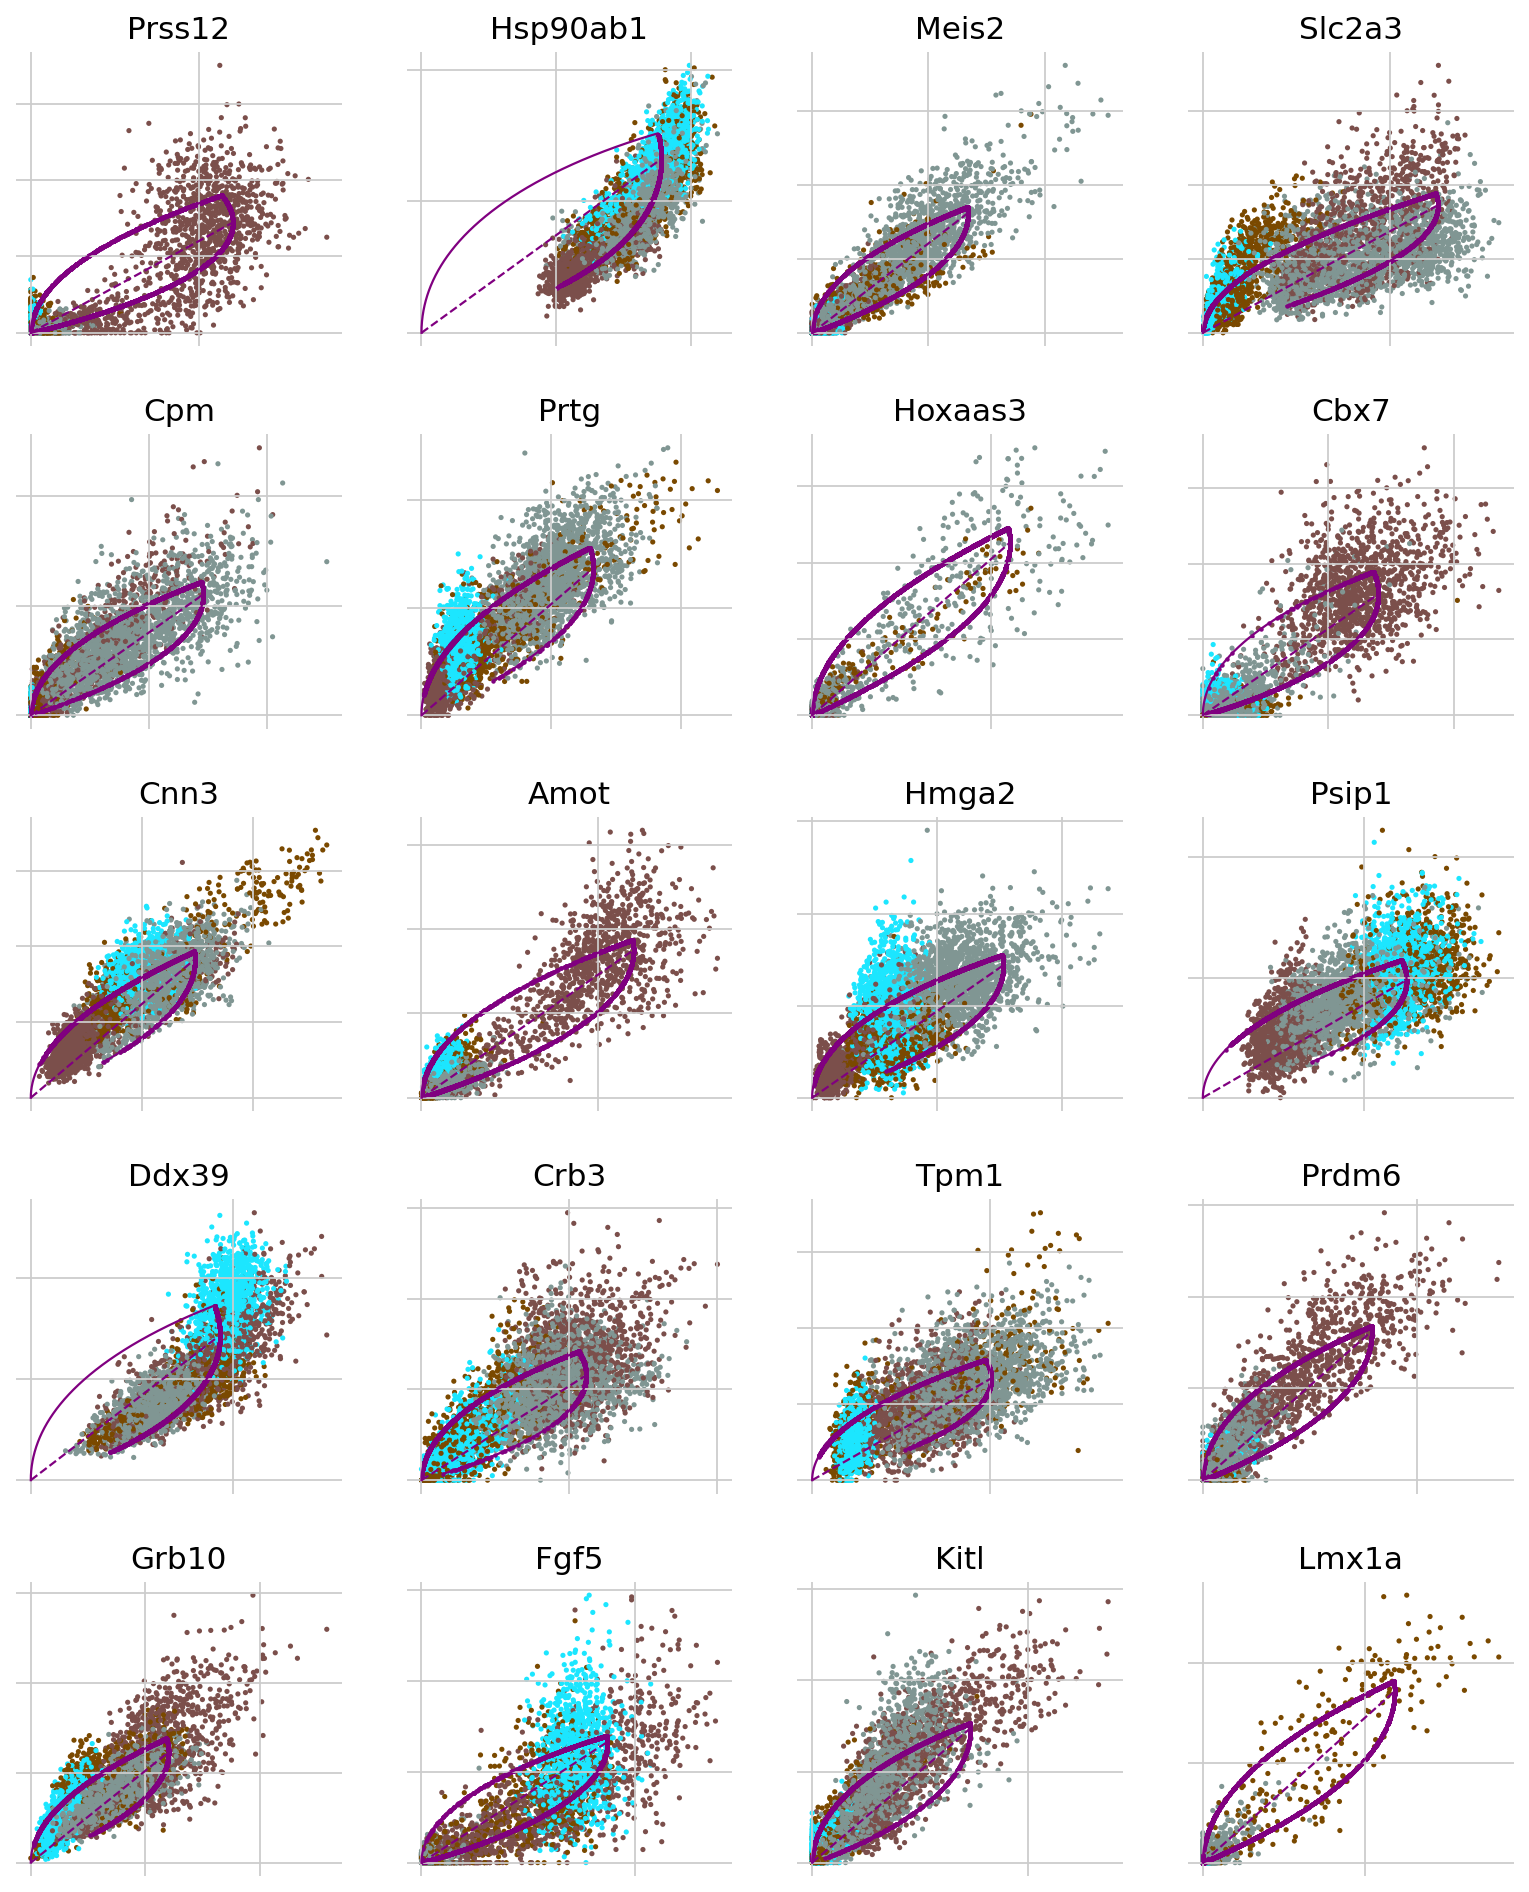

In [6]:
scv.pl.scatter(endo, basis=top_genes[:20], frameon=False, ncols=4,color='celltype')

In [23]:
var_names = top_genes[:20]
scv.tl.differential_kinetic_test(endo, var_names=var_names, groupby='celltype')
scv.get_df(endo[:, var_names], ['fit_diff_kinetics', 'fit_pval_kinetics'], precision=2)

testing for differential kinetics
    finished (0:00:03) --> added 
    'fit_diff_kinetics', clusters displaying differential kinetics (adata.var)
    'fit_pval_kinetics', p-values of differential kinetics (adata.var)


,fit_diff_kinetics,fit_pval_kinetics
index,,
Meis2,Gut,4.45e-04
Cnn3,Def. endoderm,1.34e-29
Hmga2,Anterior Primiti,2.45e-07
Ddx39,Gut,2.33e-03
Tpm1,Def. endoderm,7.52e-04
Grb10,Visceral endoder,3.85e-09


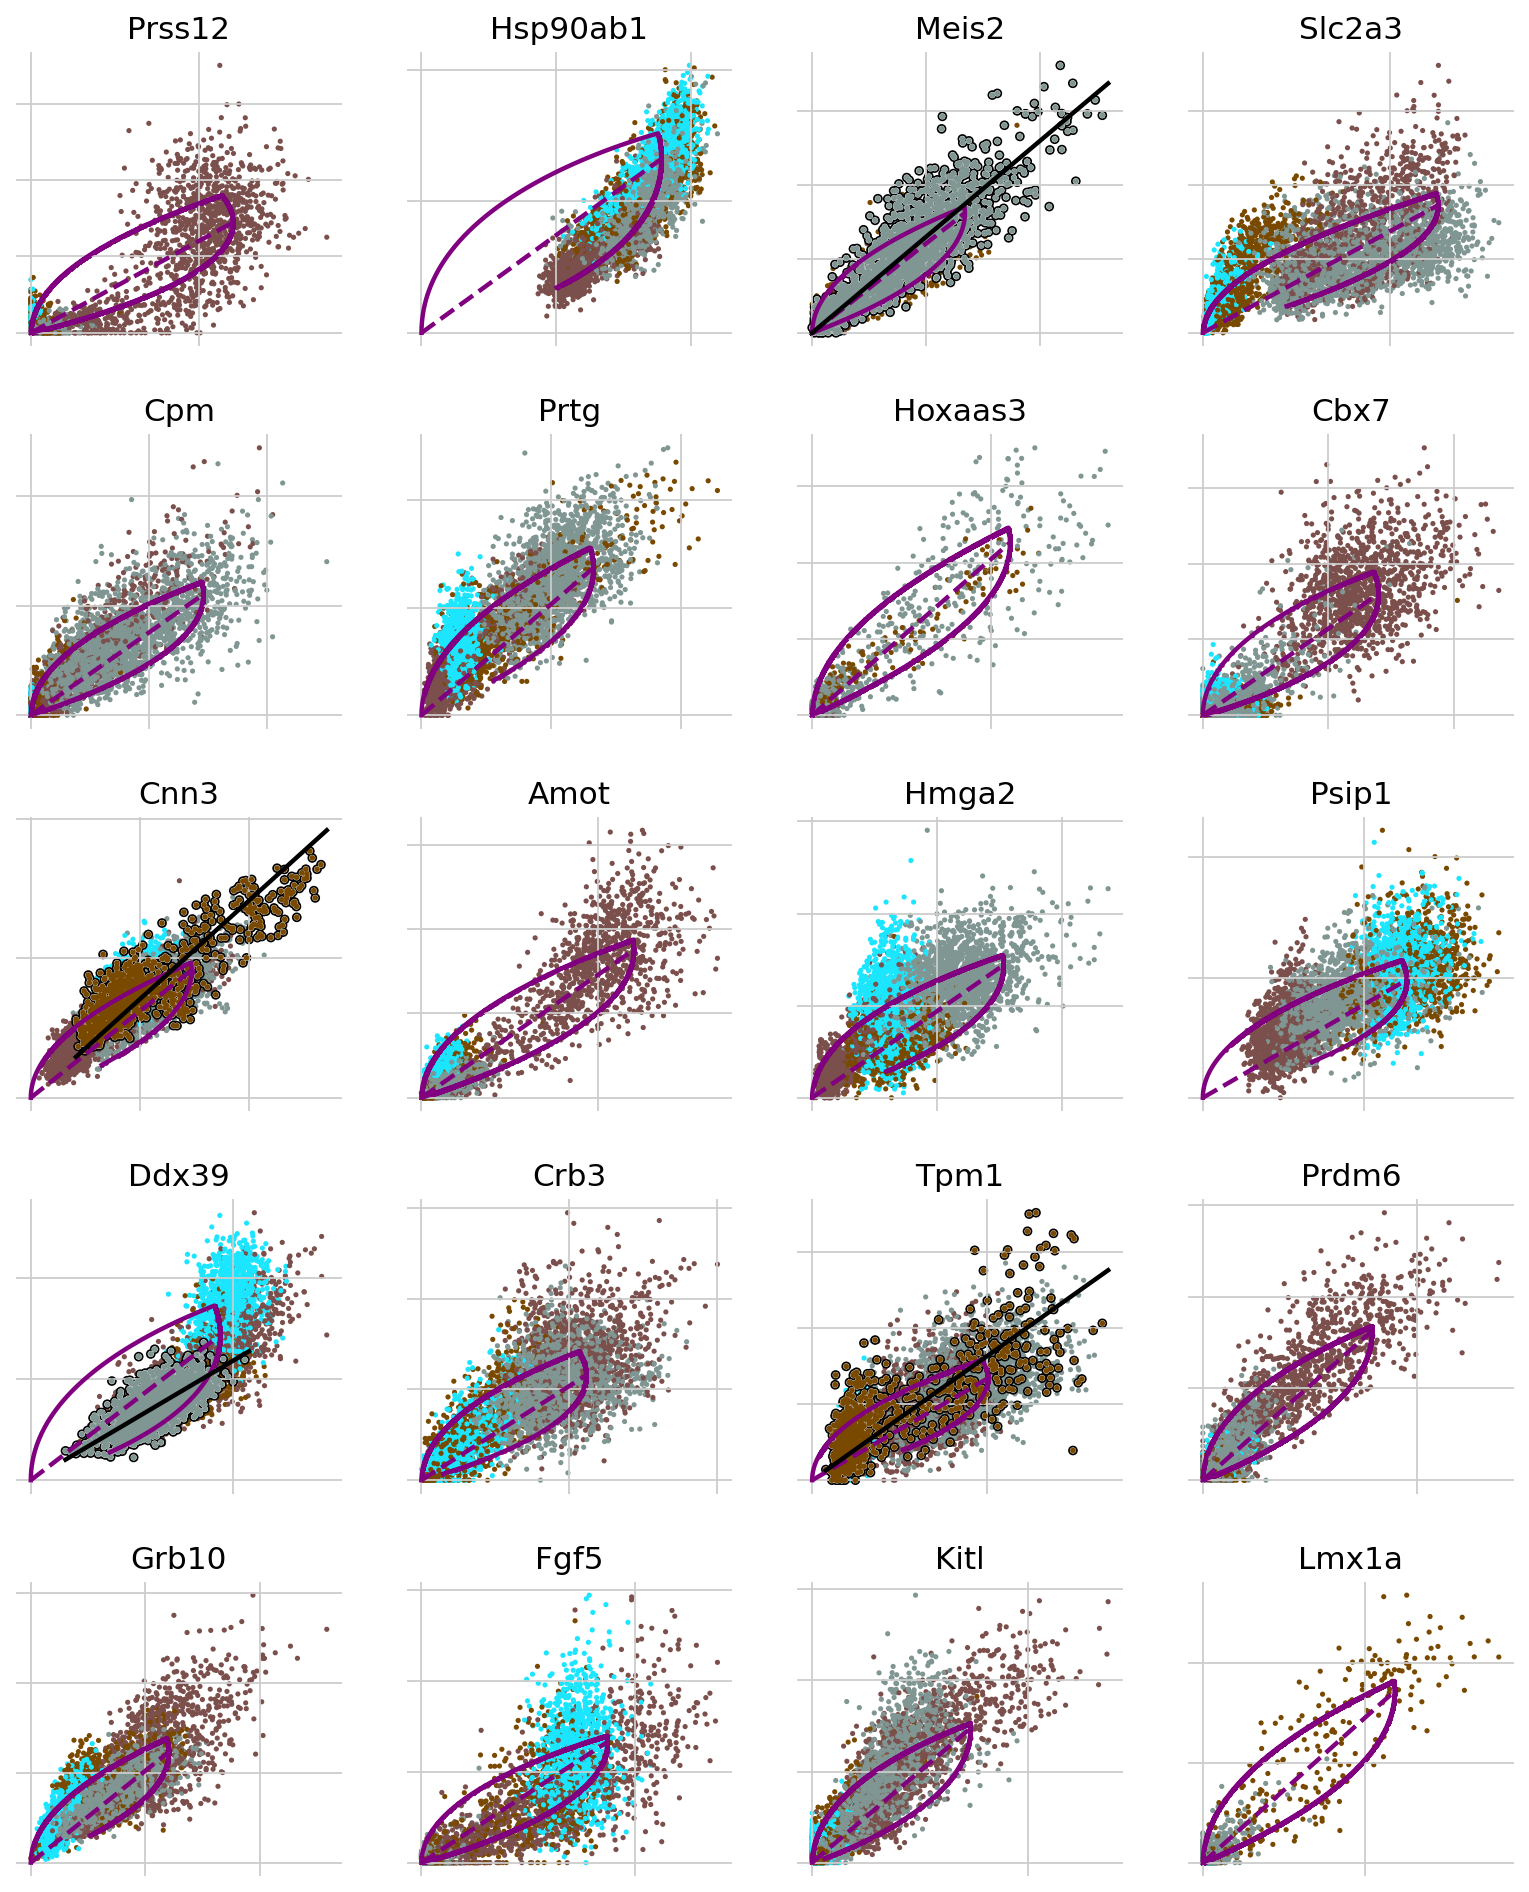

In [24]:
kwargs = dict(linewidth=2, add_linfit=True, frameon=False)
scv.pl.scatter(endo, basis=var_names, add_outline='fit_diff_kinetics', ncols=4, **kwargs)


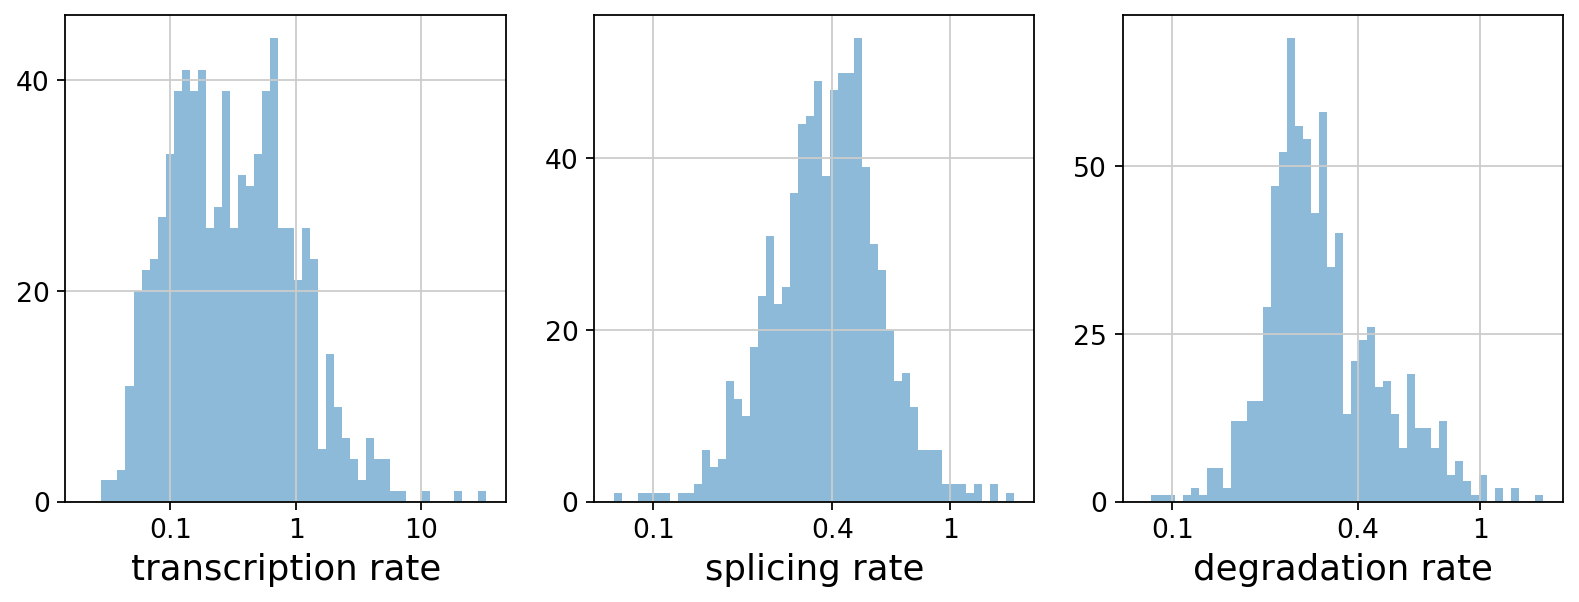

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling,fit_diff_kinetics,fit_pval_kinetics
index,,,,,,,,,,,,,,,,,,
Hmga2,0.43,1.71,2.08,0.39,12.49,0.11,0.23,0.99,0.38,0.0,0.0,0.46,0.59,2.51,0.39,2.00,Anterior Primiti,2.45e-07
Grb10,0.60,1.12,0.35,0.36,11.53,0.51,0.78,0.73,0.36,0.0,0.0,0.44,2.43,1.98,0.40,2.51,Visceral endoder,3.85e-09
Meis2,0.88,1.23,1.37,0.83,7.08,0.31,0.29,0.44,0.45,0.0,0.0,0.40,0.69,1.04,0.28,1.04,Gut,4.45e-04
Cnn3,0.58,1.45,0.70,0.44,13.32,0.30,0.48,0.75,0.40,0.0,0.0,0.37,1.68,2.47,0.35,2.12,Def. endoderm,1.34e-29
Ddx39,0.62,0.85,0.21,0.13,22.70,0.43,0.94,1.04,0.38,0.0,0.0,0.48,2.75,4.74,0.40,4.91,Gut,2.33e-03


In [25]:
df = endo.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]

kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(endo, 'fit*', dropna=True).head()


computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


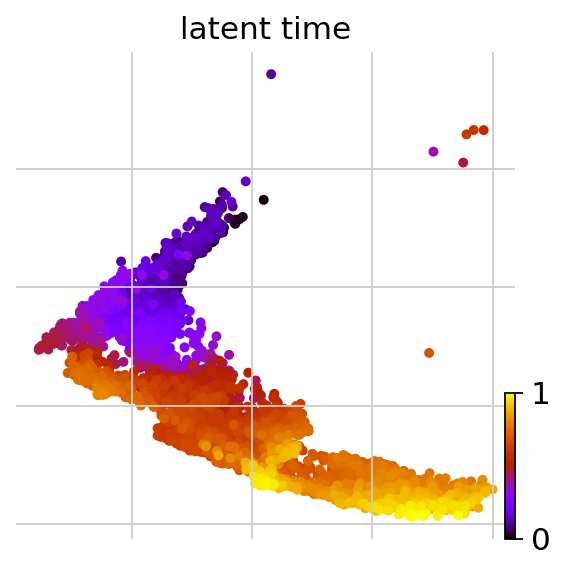

In [9]:
scv.tl.latent_time(endo)
scv.pl.scatter(endo, color='latent_time', color_map='gnuplot', size=80)

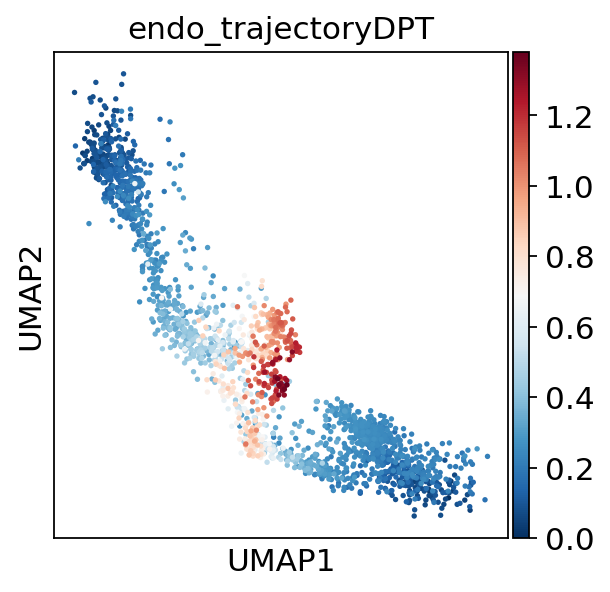

In [29]:
sc.pl.umap(endo, color='endo_trajectoryDPT')

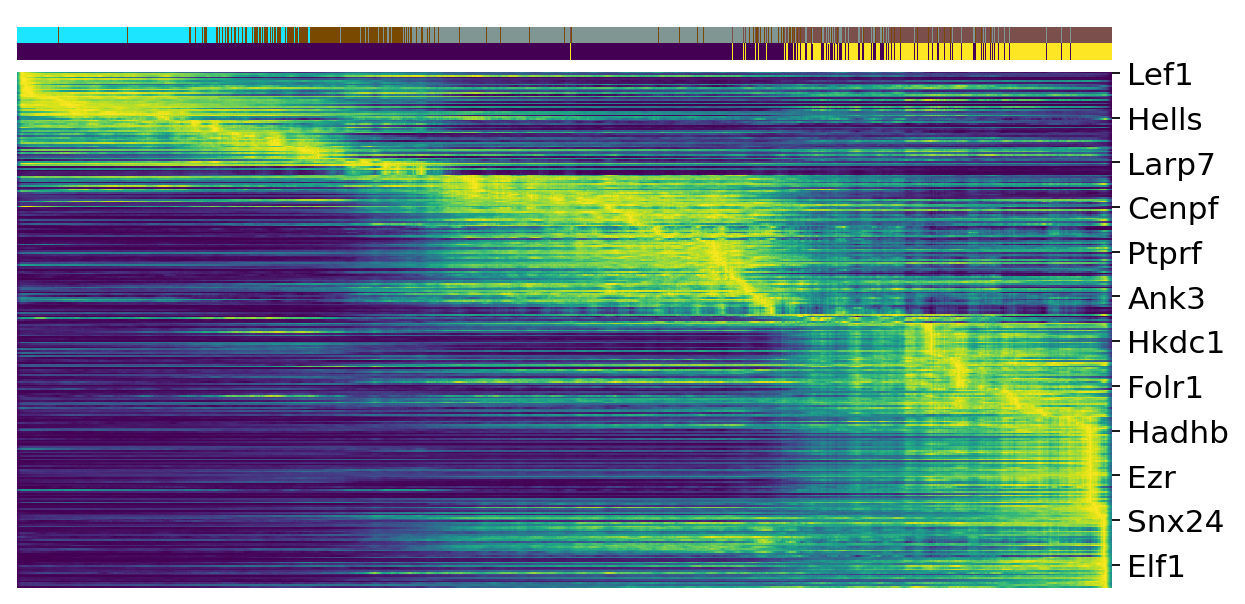

In [30]:
scv.pl.heatmap(endo, var_names=top_genes, sortby='latent_time', col_color=['celltype','cluster'], n_convolve=50)

### trying cellrank

In [7]:
endo

AnnData object with n_obs × n_vars = 5066 × 2000
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'celltype_colors', 'neighbors', 

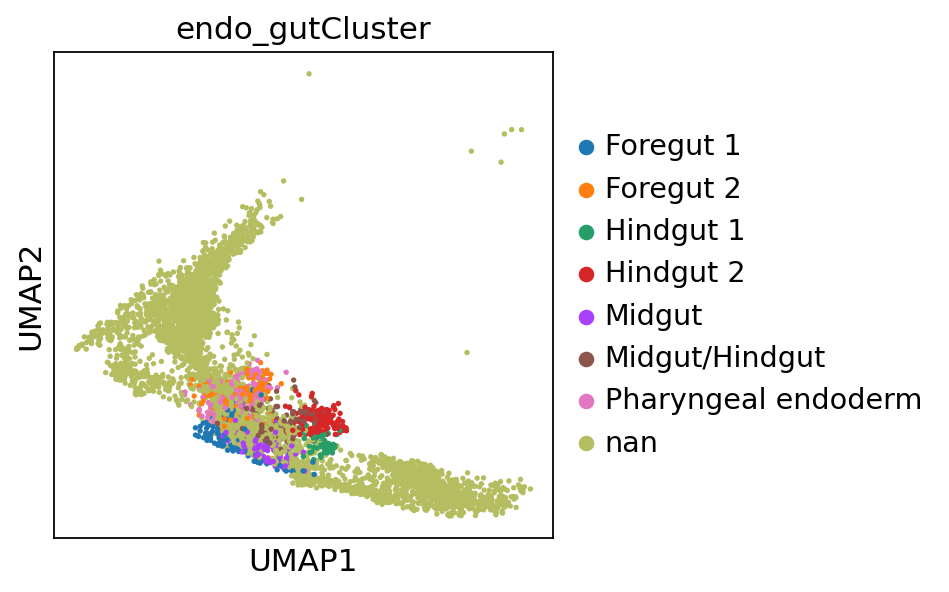

In [19]:
sc.pl.umap(endo, color='endo_gutCluster')

In [10]:
# determine terminal states
cr.tl.terminal_states(endo, n_states=1 ,cluster_key='endo_gutCluster')

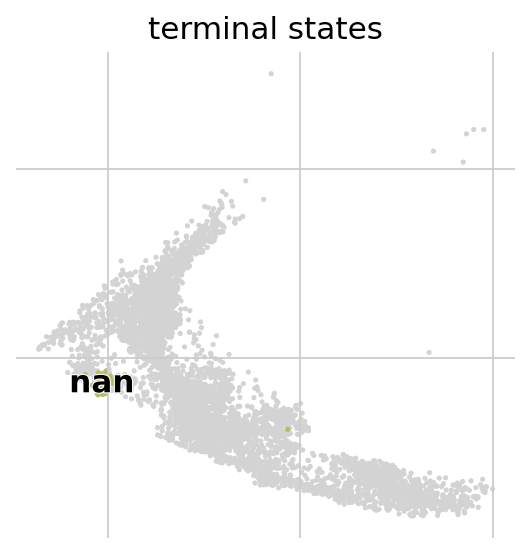

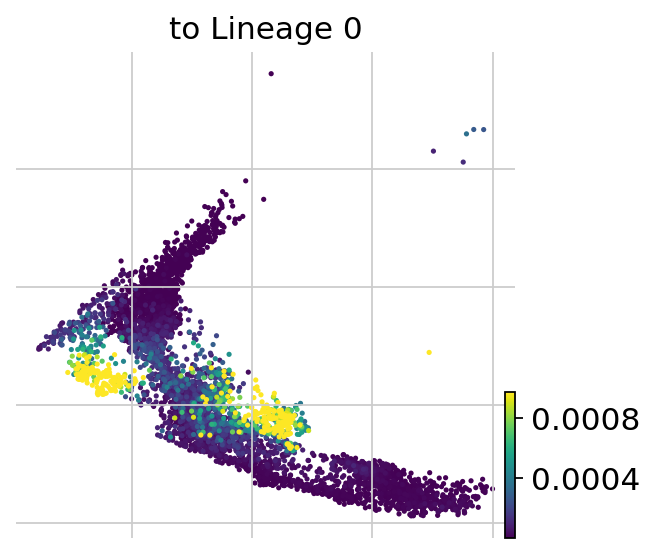

In [37]:
# plotting
cr.pl.terminal_states(endo, discrete=True)
cr.pl.terminal_states(endo)


INFO: Using pre-computed schur decomposition


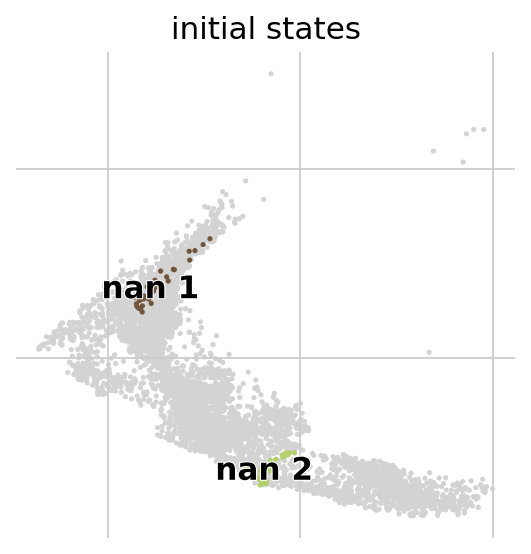

In [11]:
# determine and plot initial states
cr.tl.initial_states(endo, cluster_key='endo_gutCluster')
cr.pl.initial_states(endo, discrete=True)

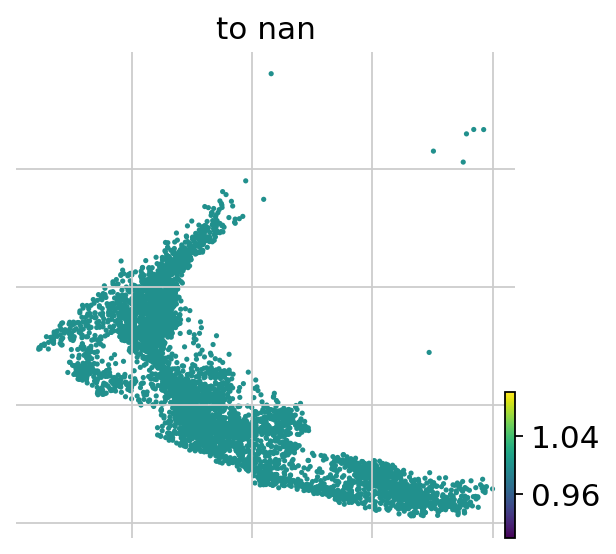

In [12]:
# compute fate maps
cr.tl.lineages(endo)
cr.pl.lineages(endo, same_plot=False)

In [13]:
endo.write('endo_test.h5')